<a href="https://colab.research.google.com/github/Georgie-J/AI-ML-Internship-Srishti-Innovatives/blob/main/day8/DogvsCatCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

In [2]:
os.environ['KAGGLE_USERNAME'] = 'georgiejacob'
os.environ['KAGGLE_KEY'] = 'KGAT_12909cda3404a2bf49f686d72aa1ad9c'

In [3]:
!pip install -q kaggle

In [4]:
# Download Dataset from Kaggle
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:06<00:00, 134MB/s]



In [5]:
# Extract Dataset
import zipfile

zip_ref = zipfile.ZipFile('microsoft-catsvsdogs-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [6]:
# Check Dataset Folders
import os

dataset_path = "/content/PetImages"

print(os.listdir(dataset_path))

['Cat', 'Dog']


In [7]:
# Remove Corrupted Images
from PIL import Image

folders = ['Cat', 'Dog']

for folder in folders:
    folder_path = os.path.join(dataset_path, folder)

    for image_file in os.listdir(folder_path):

        file_path = os.path.join(folder_path, image_file)

        try:
            img = Image.open(file_path)
            img.verify()

        except:
            os.remove(file_path)

print("Corrupted Images Removed")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted Images Removed


In [8]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [9]:
# Image Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [10]:
# Build CNN Model
model = Sequential()

# First CNN Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second CNN Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third CNN Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from PIL import Image
import os

dataset_path = "/content/PetImages"

folders = ['Cat', 'Dog']

for folder in folders:

    folder_path = os.path.join(dataset_path, folder)

    for image_file in os.listdir(folder_path):

        file_path = os.path.join(folder_path, image_file)

        try:
            img = Image.open(file_path)
            img.verify()

        except:
            print("Removing corrupted file:", file_path)
            os.remove(file_path)

print("Corrupted images removed successfully")

Corrupted images removed successfully


In [15]:
# Train Model
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1031s 2s/step - accuracy: 0.6945 - loss: 0.5803 - val_accuracy: 0.7357 - val_loss: 0.5342
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1026s 2s/step - accuracy: 0.7669 - loss: 0.4908 - val_accuracy: 0.8045 - val_loss: 0.4245
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1024s 2s/step - accuracy: 0.8160 - loss: 0.4036 - val_accuracy: 0.8139 - val_loss: 0.3975
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1032s 2s/step - accuracy: 0.8500 - loss: 0.3432 - val_accuracy: 0.8369 - val_loss: 0.3852
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1017s 2s/step - accuracy: 0.8755 - loss: 0.2922 - val_accuracy: 0.8359 - val_loss: 0.3868


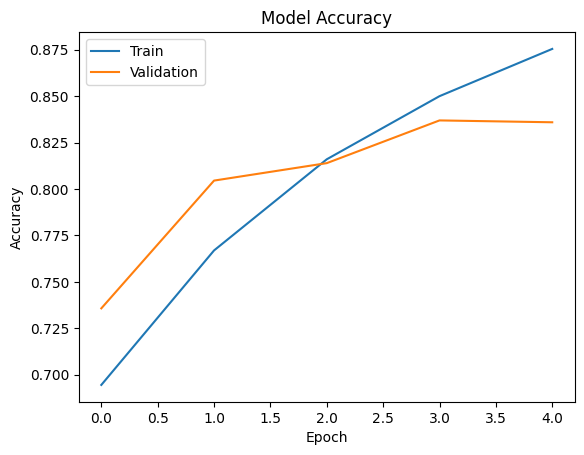

In [16]:
# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

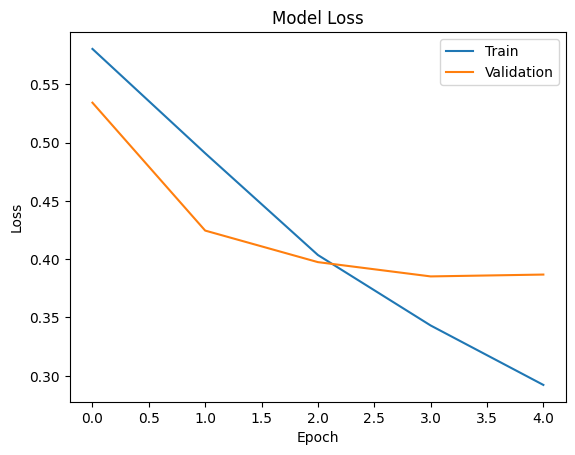

In [17]:
# Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [19]:
model.save("cat_dog_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [28]:
!pip install streamlit pyngrok

In [29]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# Load Trained Model
model = tf.keras.models.load_model("cat_dog_model.h5")

# App Title
st.title("Cat vs Dog Classifier")

st.write("Upload an image and the model will predict whether it is a cat or dog.")

# Upload Image
uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:

    # Display Image
    image = Image.open(uploaded_file)
    st.image(image, caption="Uploaded Image", use_container_width=True)

    # Preprocess Image
    img = image.resize((150,150))
    img_array = np.array(img) / 255.0

    # Ensure RGB
    if img_array.shape[-1] == 4:
        img_array = img_array[:,:,:3]

    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array)

    # Show Result
    if prediction[0][0] > 0.5:
        st.success("Prediction: Dog")
    else:
        st.success("Prediction: Cat")

Overwriting app.py


In [30]:
from pyngrok import ngrok

ngrok.set_auth_token("3DfwoRyZ6ZIfQYLlBmJQi1szIap_4S5i21mTx4vJDMNphSdqT")

In [31]:
!streamlit run app.py &>/content/logs.txt &

In [32]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://trespass-cheddar-ferris.ngrok-free.dev" -> "http://localhost:8501"
